# NOAA TAO/TRITON ENSO Data Exploration

This notebook explores observational ENSO-related data obtained from the NOAA TAO/TRITON array (5 Day).

The initial focus is on:

* Sea Surface Temperature (SST)
* 20°C Isotherm Depth (Z20)

These variables are closely related to the Recharge Oscillator framework, where SST represents sea surface conditions and Z20 serves as a proxy for thermocline depth and upper-ocean heat content.

The objectives of this notebook are:

1. Read and clean NOAA data files.
2. Assess data quality and identify missing observations.
3. Explore temporal coverage and data availability.
4. Perform exploratory data analysis of SST and Z20.
5. Investigate statistical and spectral characteristics of the data.
6. Prepare datasets for subsequent ENSO and NGRC analyses.


In [1]:
from pathlib import Path
import gzip

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 

from scipy.signal import periodogram, find_peaks

In [2]:
def clean_file(filename, variable_name="value"):
    records = []

    with gzip.open(filename, "rt") as f:
        for line in f:
            parts = line.split()

            if len(parts) == 4:
                try:
                    records.append([
                        parts[0],
                        parts[1],
                        float(parts[2]),
                        int(parts[3])
                    ])
                except ValueError:
                    pass

    df = pd.DataFrame(
        records,
        columns=["date", "time", variable_name, "quality"]
    )

    df["date"] = pd.to_datetime(
        df["date"],
        format="%Y%m%d"
    )

    return df

In [3]:
def prepare_enso_data(sst_file, z20_file):

    sst = clean_file(sst_file, "sst")
    z20 = clean_file(z20_file, "z20")

    sst_missing = (sst["sst"] == -9.99).sum()
    z20_missing = (z20["z20"] == -9.99).sum()

    print(f"SST missing values : {sst_missing}")
    print(f"Z20 missing values : {z20_missing}")

    sst["sst"] = sst["sst"].replace(-9.99, np.nan)
    z20["z20"] = z20["z20"].replace(-9.99, np.nan)

    enso = (
        sst[["date", "sst"]]
        .merge(
            z20[["date", "z20"]],
            on="date",
            how="inner"
        )
    )

    print(f"Rows before dropna : {len(enso)}")

    enso = enso.dropna()

    print(f"Rows after dropna  : {len(enso)}")

    enso["sst_anom"] = enso["sst"] - enso["sst"].mean()
    enso["z20_anom"] = enso["z20"] - enso["z20"].mean()

    return enso

In [4]:
enso = prepare_enso_data(
    "data/sst/sst0n155w_5day.ascii.gz",
    "data/z20/iso0n155w_5day.ascii.gz"
)
enso.head()

SST missing values : 1
Z20 missing values : 32
Rows before dropna : 1875
Rows after dropna  : 1844


,date,sst,z20,sst_anom,z20_anom
0,1991-07-22,28.01,138.28,1.035228,3.380629
1,1991-07-27,28.20,141.00,1.225228,6.100629
2,1991-08-01,28.04,139.92,1.065228,5.020629
3,1991-08-06,27.70,147.89,0.725228,12.990629
4,1991-08-11,27.93,147.31,0.955228,12.410629


In [5]:
def plot_time_series(enso):

    fig, ax = plt.subplots(
        2, 1,
        figsize=(12, 8),
        sharex=True
    )

    ax[0].plot(enso["date"], enso["sst"])
    ax[0].set_title("Sea Surface Temperature (SST)")
    ax[0].set_ylabel("Temperature (°C)")
    ax[0].grid(alpha=0.3)

    ax[1].plot(enso["date"], enso["z20"])
    ax[1].set_title("20°C Isotherm Depth (Z20)")
    ax[1].set_ylabel("Depth (m)")
    ax[1].set_xlabel("Year")
    ax[1].grid(alpha=0.3)

    plt.tight_layout()
    plt.show()

In [6]:
def check_gaps(enso, threshold_days=30):

    enso = enso.sort_values("date")

    delta = enso["date"].diff()

    large_gaps = enso.loc[
        delta > pd.Timedelta(days=threshold_days),
        ["date"]
    ]

    print(f"Number of gaps > {threshold_days} days: {len(large_gaps)}")

    return large_gaps

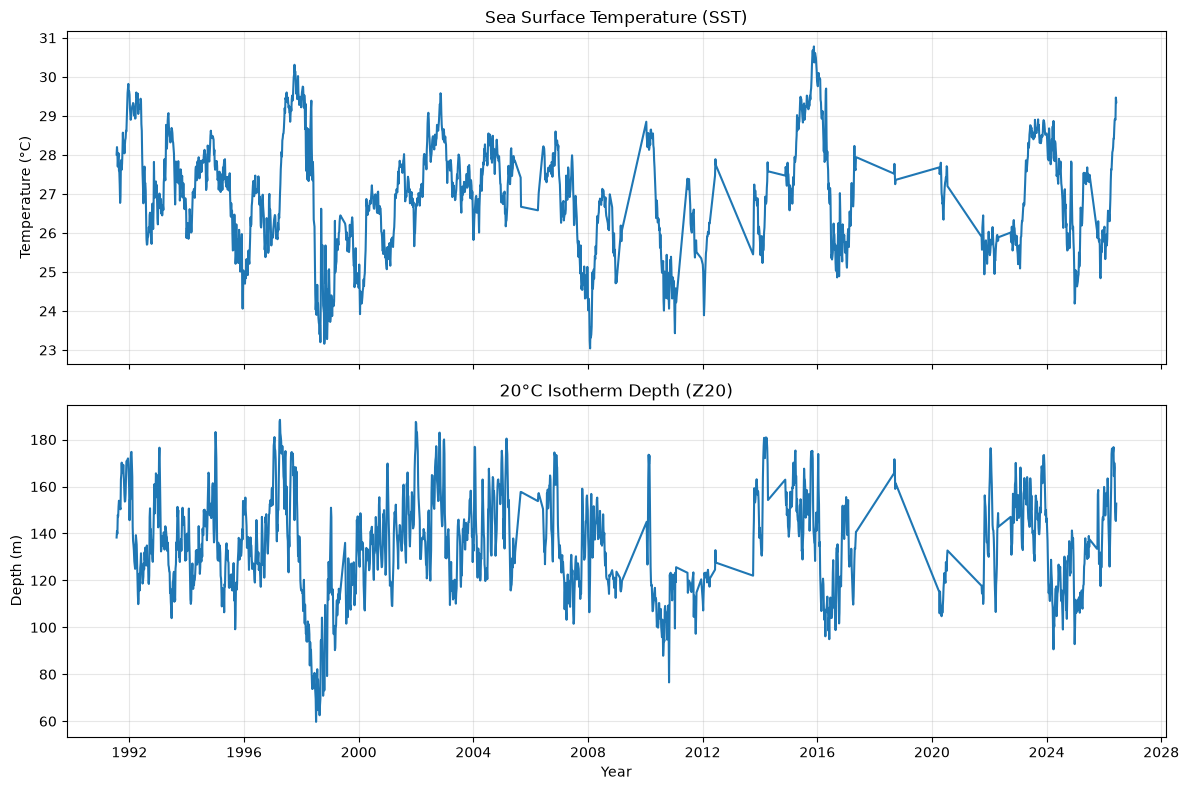

Number of gaps > 30 days: 16


,date
571,1999-07-12
1005,2005-08-26
1007,2006-04-03
1010,2006-06-07
1198,2009-02-12
1204,2010-01-13
1281,2011-06-22
1305,2011-12-14
1328,2012-06-07
1331,2013-10-05


In [7]:
plot_time_series(enso)

check_gaps(enso)

In [8]:
def plot_distributions(enso):

    fig, ax = plt.subplots(
        1, 2,
        figsize=(12, 4)
    )

    ax[0].hist(enso["sst"], bins=30)
    ax[0].set_title("Distribution of SST")
    ax[0].set_xlabel("SST (°C)")
    ax[0].set_ylabel("Frequency")
    ax[0].grid(alpha=0.3)

    ax[1].hist(enso["z20"], bins=30)
    ax[1].set_title("Distribution of Z20")
    ax[1].set_xlabel("Z20 (m)")
    ax[1].set_ylabel("Frequency")
    ax[1].grid(alpha=0.3)

    fig.suptitle("Distributions of SST and Z20")

    plt.tight_layout()
    plt.show()

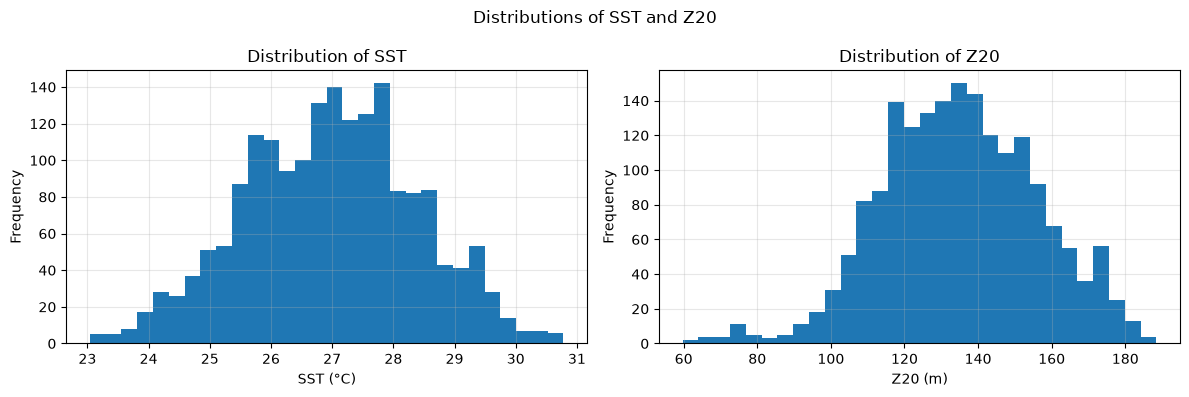

In [9]:
plot_distributions(enso)

In [10]:
def plot_scatter(enso):

    corr = enso["sst"].corr(
        enso["z20"]
    )

    plt.figure(figsize=(6, 6))

    plt.scatter(
        enso["z20"],
        enso["sst"],
        alpha=0.4
    )

    plt.title(
        f"SST vs Z20 (r = {corr:.2f})"
    )

    plt.xlabel("Z20 (m)")
    plt.ylabel("SST (°C)")
    plt.grid(alpha=0.3)

    plt.show()

    print(f"Correlation: {corr:.3f}")

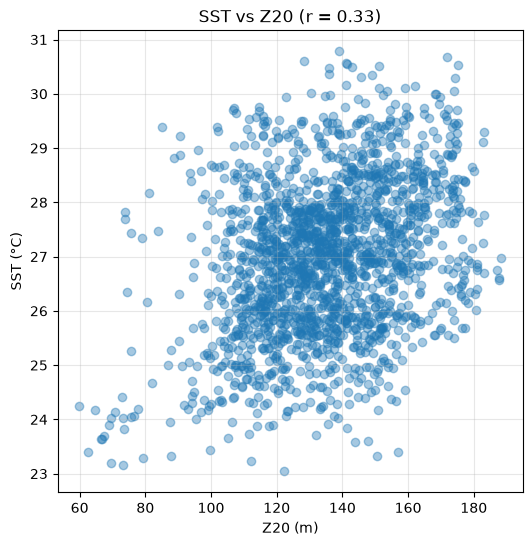

Correlation: 0.326


In [11]:
plot_scatter(enso)

In [12]:
def lag_analysis(enso, max_lag=100):

    lags = range(-max_lag, max_lag + 1)

    corrs = [
        enso["sst"].corr(
            enso["z20"].shift(lag)
        )
        for lag in lags
    ]

    best_idx = np.nanargmax(corrs)
    best_lag = lags[best_idx]
    best_corr = corrs[best_idx]

    plt.figure(figsize=(8, 4))

    plt.plot(lags, corrs)
    plt.axvline(
        best_lag,
        color="red",
        linestyle="--",
        label=f"Peak lag = {best_lag}"
    )

    plt.axhline(
        0,
        color="black",
        linestyle=":"
    )

    plt.xlabel("Lag (5-day intervals)")
    plt.ylabel("Correlation")
    plt.title("Lag Correlation Between SST and Z20")

    plt.legend()
    plt.grid(alpha=0.3)

    plt.show()

    print(f"Best lag: {best_lag}")
    print(f"Best correlation: {best_corr:.3f}")

    return best_lag, best_corr

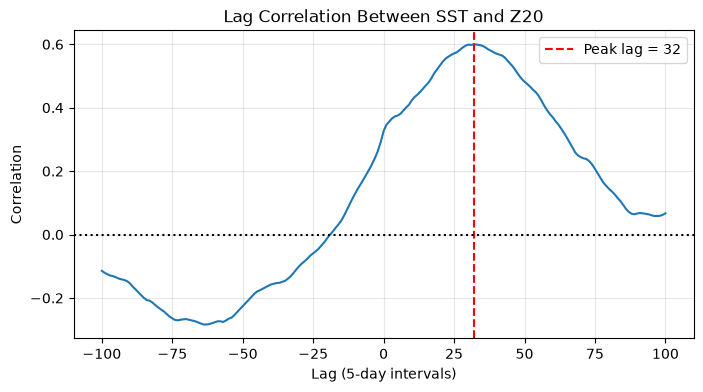

Best lag: 32
Best correlation: 0.599


In [13]:
best_lag, best_corr = lag_analysis(enso)

In [14]:
def spectral_analysis(series, name):

    freqs, power = periodogram(
        series,
        fs=1/5
    )

    plt.figure(figsize=(9, 4))

    plt.plot(
        1 / freqs[1:],
        power[1:],
        linewidth=1.5
    )

    plt.xlim(0, 3000)

    plt.xlabel("Period (days)")
    plt.ylabel("Power")
    plt.title(f"Power Spectrum of {name}")

    plt.grid(alpha=0.3)
    plt.tight_layout()

    plt.show()

    peaks, _ = find_peaks(power)

    top = pd.DataFrame({
        "period_days": 1 / freqs[peaks],
        "power": power[peaks]
    })

    return top.sort_values(
        "power",
        ascending=False
    ).head(10)

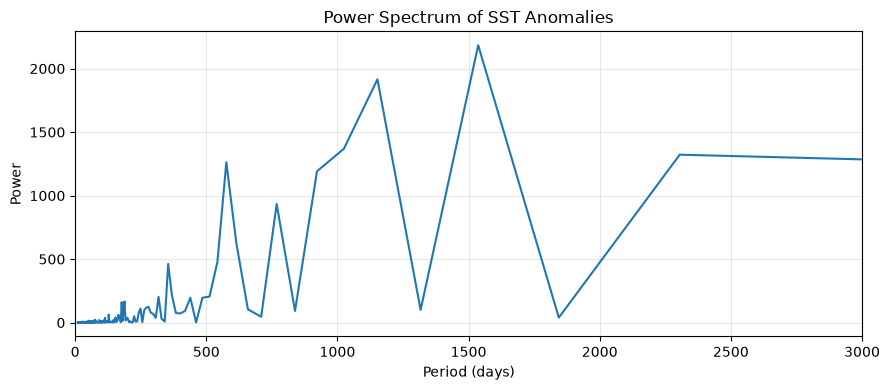

,period_days,power
1,1536.666667,2184.041641
2,1152.500000,1915.438053
0,2305.000000,1322.069666
4,576.250000,1262.264754
3,768.333333,934.282112
6,354.615385,461.745018
7,317.931034,202.805346
5,439.047619,195.928311
13,188.163265,166.842223
14,177.307692,160.819542


In [15]:
sst_peaks = spectral_analysis(
    enso["sst_anom"],
    "SST Anomalies"
)
sst_peaks

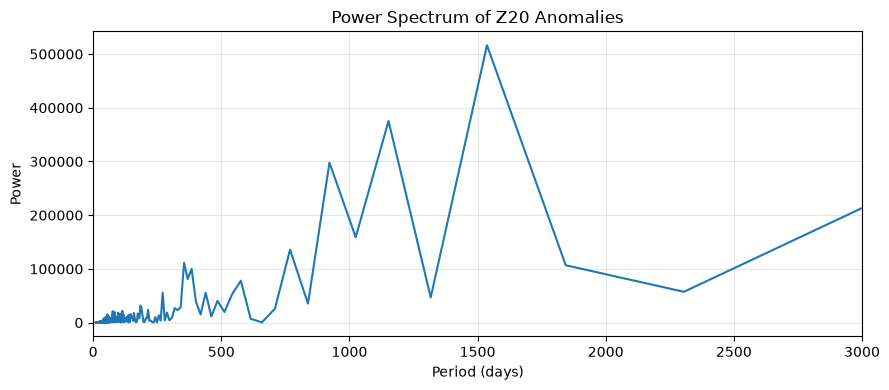

,period_days,power
1,1536.666667,516515.159611
2,1152.500000,375387.672057
3,922.000000,297881.017254
0,3073.333333,229742.789265
4,768.333333,135827.554609
9,354.615385,111459.855728
8,384.166667,100030.973435
5,576.250000,78039.350005
12,271.176471,55818.990954
7,439.047619,55646.497491


In [16]:

z20_peaks = spectral_analysis(
    enso["z20_anom"],
    "Z20 Anomalies"
)

z20_peaks

In [17]:
def run_eda(sst_file, z20_file):

    enso = prepare_enso_data(
        sst_file,
        z20_file
    )

    plot_time_series(enso)

    check_gaps(enso)

    plot_distributions(enso)

    plot_scatter(enso)

    best_lag, best_corr = lag_analysis(enso)

    sst_peaks = spectral_analysis(
        enso["sst_anom"],
        "SST Anomalies"
    )

    z20_peaks = spectral_analysis(
        enso["z20_anom"],
        "Z20 Anomalies"
    )

    return {
        "best_lag": best_lag,
        "best_corr": best_corr,
        "sst_peaks": sst_peaks,
        "z20_peaks": z20_peaks
    }

In [18]:
#results = run_eda( "data/sst/sst0n140w_5day.ascii.gz", "data/z20/iso0n140w_5day.ascii.gz" )